# Convolutional Autoencoders

![autoencoder](notebook_images/autoencoder.jpg)



A **convolutional autoencoder** is a neural network architecture designed to learn efficient representations of image data by compressing and reconstructing images. It consists of two main parts:

- **Encoder:** This component processes the input image through a series of convolutional layers, gradually reducing its spatial dimensions and complexity. The encoder outputs a compact, lower-dimensional representation called the **latent space**. The latent space acts as a bottleneck that captures the most essential features of the image in a compressed form.

- **Decoder:** The decoder takes this **latent space** representation and reconstructs an image by progressively upsampling and/or applying transposed convolutional layers. 

While the output is often intended to be a reconstruction of the input, it does not have to be identical. In tasks like denoising or colorization, the output image may differ intentionally.

## Unsupervised Learning

Convolutional autoencoders are typically trained using **unsupervised learning**:

- Training data consists solely of images, without labels or annotations.
- The network learns by minimizing the difference (e.g., mean squared error) between the input images and their reconstructions.
- Through this process, the autoencoder discovers meaningful patterns and compresses the data into the latent space.

## Applications

Common applications of convolutional autoencoders include:

- **Dimensionality Reduction:** Compressing images into compact feature vectors;
- **Image Denoising:** Removing noise from images;
- **Anomaly Detection:** Spotting unusual images via reconstruction error;
- **Image Colorization:** Adding color to grayscale images;
- **Image Inpainting:** Filling in missing parts of images.



## References for Additional Material:

- *Auto-Encoders in Deep Learning—A Review with New Perspectives*, Shuangshuang Chen and Wei Guo - https://www.mdpi.com/2227-7390/11/8/1777

- *Autoencoders in Deep Learning: Tutorial & Use Cases*, Hmrishav Bandyopadhyay - https://www.v7labs.com/blog/autoencoders-guide

- *Introduction to Autoencoders*, Aditya Sharma - https://pyimagesearch.com/2023/07/10/introduction-to-autoencoders/

- *Introduction to Autoencoders: From The Basics to Advanced Applications in PyTorch*, Pier Paolo Ippolito - https://www.datacamp.com/tutorial/introduction-to-autoencoders

- *Auto-Encoder: What Is It? And What Is It Used For?*, Will Badr -https://towardsdatascience.com/applied-deep-learning-part-3-autoencoders-1c083af4d798




In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time
import glob


import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

print(torch.__version__)

2.2.1+cu118


## Auxiliary functions for training, evaluation and result visualization

The focus here is on the architecture and applications of autoencoders (AEs), rather that the training process itself. As the training procedure is similar to that of CNNs, these functions are imported from earlier notebooks in this course

In [2]:
def train(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}

    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, _) in tqdm(enumerate(train_loader, 0)):
            
            inputs = inputs.to(device)
    
            outputs = model(inputs)
    
            loss = loss_fn(outputs, inputs)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.cpu().detach().numpy()
     
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i,_ in val_loader:
                i = i.to(device)
                o = model(i)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, i).cpu().detach().numpy()


        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; \
              Val Loss: {val_loss:0.6f}; \
              Elapsed time: {(stop_time - start_time):0.4f}')

        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')
            best_val_loss = val_loss

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def train_denoiser(model, train_loader, val_loader, epochs, loss_fn, 
                   optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}

    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets,classes) in tqdm(enumerate(train_loader, 0)):
            
            inputs = inputs.to(device)
            targets = targets.to(device)
    
            outputs = model(inputs)
    
            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.cpu().detach().numpy()
     
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i,t,_ in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t).cpu().detach().numpy()


        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; \
              Val Loss: {val_loss:0.6f}; \
              Elapsed time: {(stop_time - start_time):0.4f}')

        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')
            best_val_loss = val_loss

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)

    
class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    
from matplotlib import colors

def plot_scatter(x,y,targets, lims = None):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    if lims != None:
        s = 50
    else: s = 1

    plt.figure(figsize=(10,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = s, norm=norm)
    plt.colorbar()
    if lims != None:
         plt.xlim(lims[0], lims[2])
         plt.ylim(lims[1], lims[3])

    plt.show()


def show_preds(set1, set2, count):
  
  columns = 4
  rows = int(count*2 / columns) + 1  
  plt.figure(figsize=(count, 2 * rows))
  
  for n in range(count):
      ax = plt.subplot(rows, columns, n*2+1)
      plt.title("original")
      plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')
      ax = plt.subplot(rows, columns, n*2+2)
      plt.title("reconstruction")
      plt.imshow(np.transpose(set2[n].cpu().detach().numpy(), (1,2,0)), 
                 cmap=plt.cm.gray)
      plt.axis('off')        


def show_images(rows, cols, images, targets):

    width= 2 * rows
    height= 2 * cols

    f, axes= plt.subplots(rows,cols,figsize=(height,width))
    fig=plt.figure()

    for a in range(rows*cols):
        img, target = images[a], targets[a]
        axes.ravel()[a].imshow(np.transpose(img.numpy(),(1,2,0)), 
                               cmap=plt.cm.gray)
        axes.ravel()[a].axis('off')
    fig.tight_layout()    
    plt.show()          


def show_content_retrieval(train_X, top50):

    fig = plt.figure(figsize=(10,50))
    for i in range(len(top50)):
        ax = plt.subplot(25,5,i+1)
        plt.imshow(np.transpose(train_X[top50[i][1]][0], (1,2,0)), 
                   cmap='gray')
        plt.title(f'{top50[i][0]:.3f}')
        plt.axis('off')   



def show_anomaly_sample(image, recon, err):
        plt.figure(figsize=(5,2))
        ax = plt.subplot(1,2,1)
        plt.imshow(image, cmap='gray')
        plt.title(str(err))
        ax = plt.subplot(1,2,2)
        plt.imshow(recon, cmap='gray')
        plt.axis('off')



# Configuration

In [3]:
HEIGHT = 28
WIDTH = 28
NUM_CHANNELS = 1
BATCH_SIZE = 32
LATENT_SPACE_DIM = 2

MODEL_PATH = 'autoencoder_models'

# defines if training, or using already pre-trained models. 
# Set to TRUE in the first run 
# of this notebook, and FALSE for subsequent runs
TRAIN = False

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# Load and prepare MNIST dataset

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

full_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_set, val_set = torch.utils.data.random_split(full_dataset, 
                                                   [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, 
                                           shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

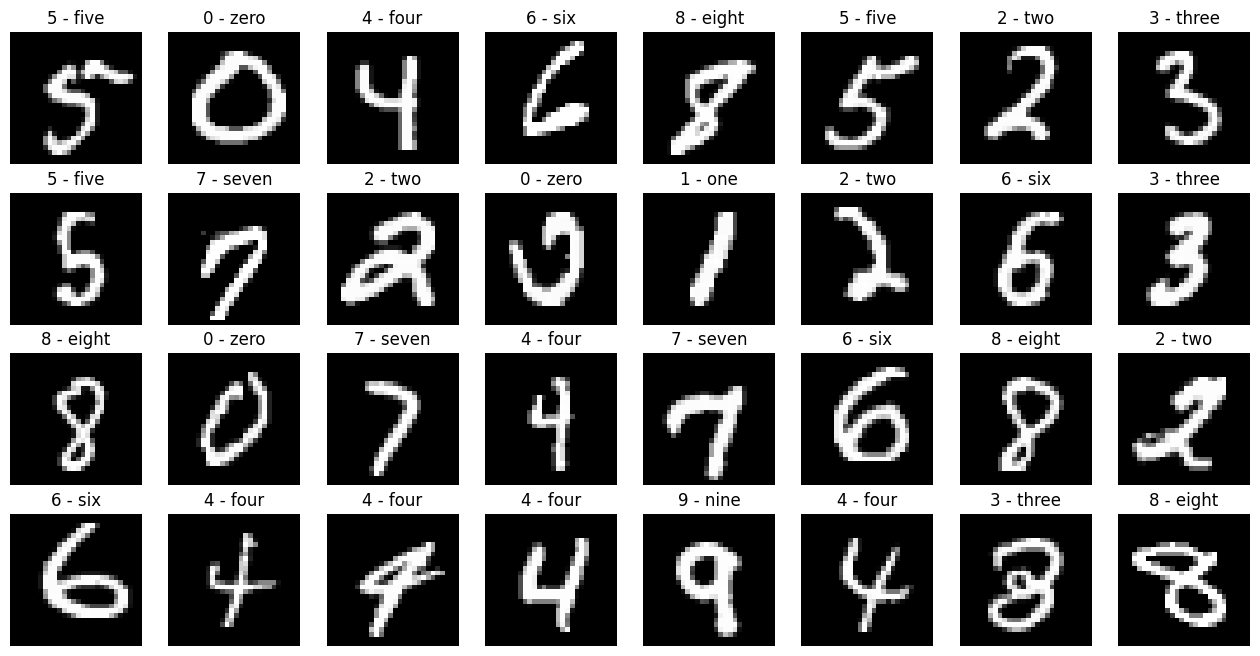

<Figure size 640x480 with 0 Axes>

In [5]:
images, targets = next(iter(train_loader))

vcpi_util.show_images(4,8, images, targets, full_dataset.classes) 

# Autoencoder for reconstruction

![reconstruction](notebook_images/autoencoder_reconstruction.jpg)

In this example, we use an autoencoder to learn how to reconstruct its input—producing an output that closely matches the original data. 

The autoencoder achieves this by compressing the input into a compact latent space and then decompressing it back to its original form. Once the model has learned to decode this latent representation, we can experiment by feeding new or modified values into the decoder. This allows us to generate novel images that resemble, but are not identical to, those in the training set.

### Architecture

- **Encoder**: A sequence of convolutional blocks (Conv -> ReLU -> BN). Stride 2 is used in the convolutional layers to progressively reduce the spatial dimensions of the input.

- **Latent Space**: The compressed representation is produced by a dense layer. The number of units in this layer is specified as a parameter when constructing the model.

- **Decoder**: A sequence of transposed convolutional blocks that gradually upsample the latent representation, up until matching the dimensions of the input image.

In [6]:
class AutoEncoder(torch.nn.Module):

    def __init__(self, latent_space_dim):
        super().__init__()

        # encoder layers
        self.econv1 = torch.nn.Conv2d(in_channels = 1, out_channels = 32, 
                                      kernel_size= 3, stride = 2)
        self.ebn1 = torch.nn.BatchNorm2d(32)
        self.erelu1 = torch.nn.ReLU()

        self.econv2 = torch.nn.Conv2d(in_channels = 32, out_channels = 64, 
                                      kernel_size= 3, stride = 2)
        self.ebn2 = torch.nn.BatchNorm2d(64)
        self.erelu2 = torch.nn.ReLU()

        self.efc1 = torch.nn.Linear(3136, latent_space_dim)

        #decoder layers

        self.dfc1 = torch.nn.Linear(latent_space_dim, 3136)

        self.dconvT1 = torch.nn.ConvTranspose2d(in_channels = 64, out_channels = 32, 
                                                kernel_size= 3, stride = 2,
                                                padding = 1, output_padding=1)
        self.dbn1 = torch.nn.BatchNorm2d(32)
        self.drelu1 = torch.nn.ReLU()

        self.dconvT2 = torch.nn.ConvTranspose2d(in_channels = 32, out_channels = 1, 
                                                kernel_size= 3, stride = 2, 
                                                padding = 1, output_padding = 1)
        self.dsig = torch.nn.Sigmoid()

    def encoder(self, x):

        x = torch.nn.functional.pad(x, (0,1,0,1)) # pad left, right, top, bottom
        x = self.econv1(x)
        x = self.erelu1(x)
        x = self.ebn1(x)

        x = torch.nn.functional.pad(x, (0,1,0,1)) # pad left, right, top, bottom
        x = self.econv2(x)
        x = self.erelu2(x)
        x = self.ebn2(x)

        x = torch.flatten(x,1)
        x = self.efc1(x)

        return x
        
    def decoder(self,x):

        x = self.dfc1(x)
        x = x.reshape(-1, 64, 7, 7)
        x = self.dconvT1(x)
        x = self.drelu1(x)
        x = self.dbn1(x)

        x = self.dconvT2(x)
        x = self.dsig(x)

        return x

    def forward(self,x):

        encoded = self.encoder(x)
        output = self. decoder(encoded)
        return output    


Creating the model

In [7]:
AE = AutoEncoder(LATENT_SPACE_DIM)
AE.to(device)
print(AE)

torchinfo.summary(AE, input_size=(BATCH_SIZE, 1, 28, 28))

AutoEncoder(
  (econv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2))
  (ebn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (erelu1): ReLU()
  (econv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
  (ebn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (erelu2): ReLU()
  (efc1): Linear(in_features=3136, out_features=2, bias=True)
  (dfc1): Linear(in_features=2, out_features=3136, bias=True)
  (dconvT1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dbn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drelu1): ReLU()
  (dconvT2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (dsig): Sigmoid()
)


Layer (type:depth-idx)                   Output Shape              Param #
AutoEncoder                              [32, 1, 28, 28]           --
├─Conv2d: 1-1                            [32, 32, 14, 14]          320
├─ReLU: 1-2                              [32, 32, 14, 14]          --
├─BatchNorm2d: 1-3                       [32, 32, 14, 14]          64
├─Conv2d: 1-4                            [32, 64, 7, 7]            18,496
├─ReLU: 1-5                              [32, 64, 7, 7]            --
├─BatchNorm2d: 1-6                       [32, 64, 7, 7]            128
├─Linear: 1-7                            [32, 2]                   6,274
├─Linear: 1-8                            [32, 3136]                9,408
├─ConvTranspose2d: 1-9                   [32, 32, 14, 14]          18,464
├─ReLU: 1-10                             [32, 32, 14, 14]          --
├─BatchNorm2d: 1-11                      [32, 32, 14, 14]          64
├─ConvTranspose2d: 1-12                  [32, 1, 28, 28]           28

### Train models

Models will be trained for several latent space dimensions

In [8]:
latent_dims = [2,4,8,16]

loss_fn = torch.nn.loss_fn = torch.nn.MSELoss()

if TRAIN:
    for ld in latent_dims:
        
        AE = AutoEncoder(ld)
        AE.to(device)

        opt = torch.optim.Adam(AE.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 
                                        mode='min', factor = 0.1, patience=3)
        early_stop = Early_Stopping(9)
        
        history=train(AE, train_loader, val_loader, 100, loss_fn, opt,  
                      scheduler, early_stop, 
                      f'{MODEL_PATH}/autoencoder_{ld}' )

### Plotting the losses for the trained models

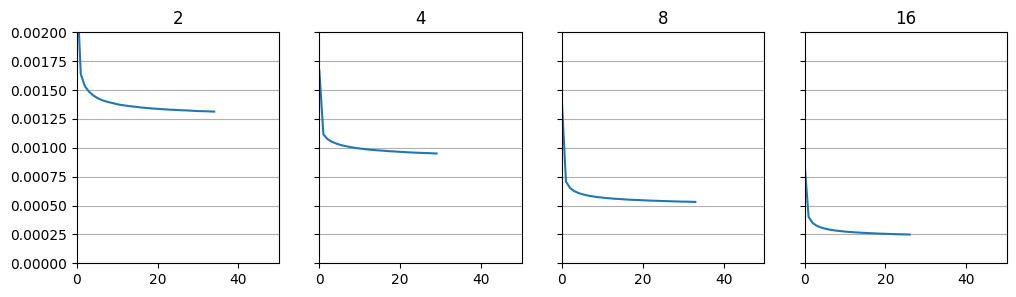

<Figure size 640x480 with 0 Axes>

In [9]:
latent_dims = [2,4,8,16]

f, axes= plt.subplots(1,4, figsize=(12,3))
fig=plt.figure()  

for index, i in enumerate(latent_dims):
    reload = torch.load(f'{MODEL_PATH}/autoencoder_{i}_best.pt')
    history = reload['history']
    axes[index].plot(history['loss'])
    axes[index].set_ylim(0, 0.002)
    axes[index].set_xlim(0, 50)
    axes[index].set_title(f'{i}')
    axes[index].grid(axis = 'y')
    if index > 0:
        axes[index].set_yticklabels([])

    
plt.show()

In [10]:
LATENT_SPACE_DIM = 2
reload = torch.load(f'{MODEL_PATH}/autoencoder_{LATENT_SPACE_DIM}_best.pt')
AE = AutoEncoder(LATENT_SPACE_DIM)
AE.to(device)
AE.load_state_dict(reload['model'])

<All keys matched successfully>

### Evaluate

A latent space with only two elements is clearly not sufficient to rebuilt the inputs. However, using two elements only allows us to create some meaningful plots that help to illustrate the full potential of the autoencoder.

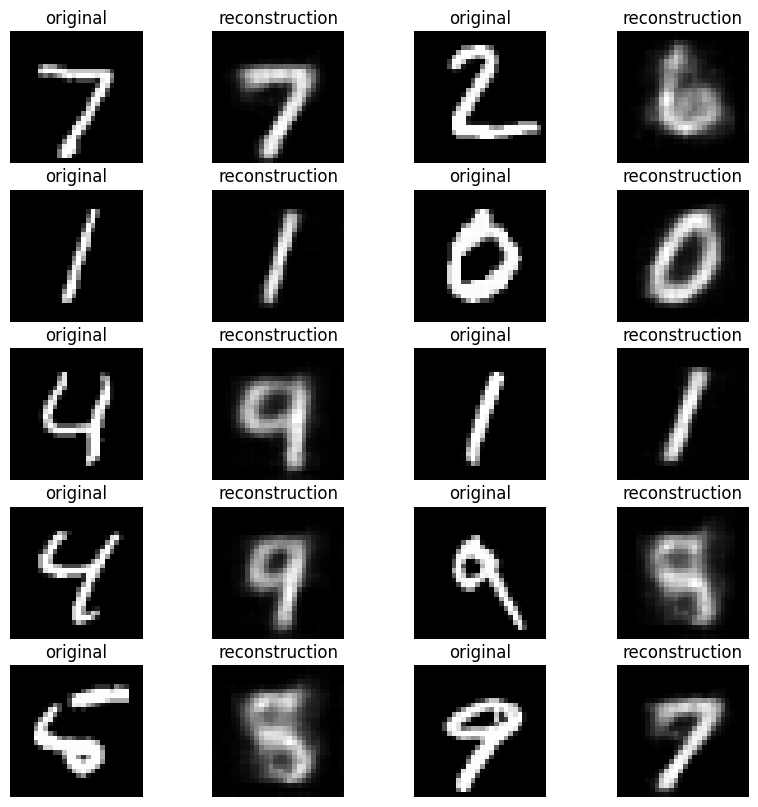

In [11]:
i, _ = next(iter(test_loader))
recon = AE(i.to(device))
    
show_preds(i, recon, 10)

### Plotting the latent space with class color coding

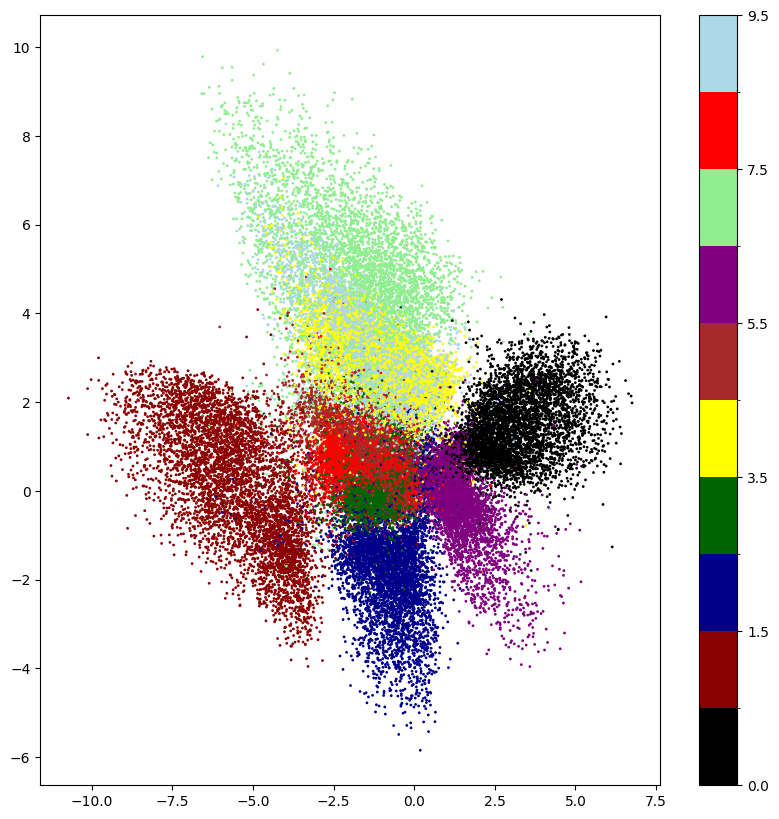

In [12]:
# this only works if the latent space dimension is 2

if LATENT_SPACE_DIM == 2:

    encoded = []
    targets = []
    for i,t in train_loader:
        encoded.extend(AE.encoder(i.to(device)).cpu().detach().numpy())
        targets.extend(t)

    x = np.array(encoded)[:,0]
    y = np.array(encoded)[:,1]

    plot_scatter(x,y,targets)#, [2,-1, 2.5, -0.5])


Show a reconstruction from a new latent space 

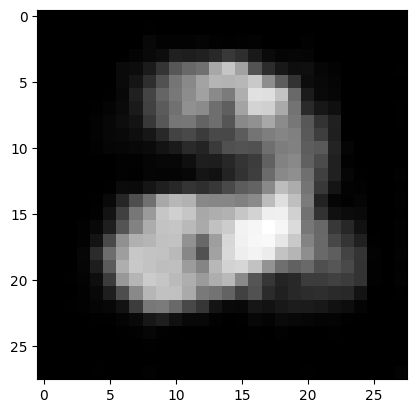

In [13]:
# change the point coordinates to obtain the different digits
point = [0,-2]

if LATENT_SPACE_DIM == 2:
    pred = AE.decoder(torch.Tensor([point]).to(device))
    plt.imshow(np.transpose(pred[0].cpu().detach().numpy(), (1,2,0)), 
               cmap=plt.cm.gray)

### Exploring the latent space

Exploring latent space in the interval [-5,5] for each of its dimensions

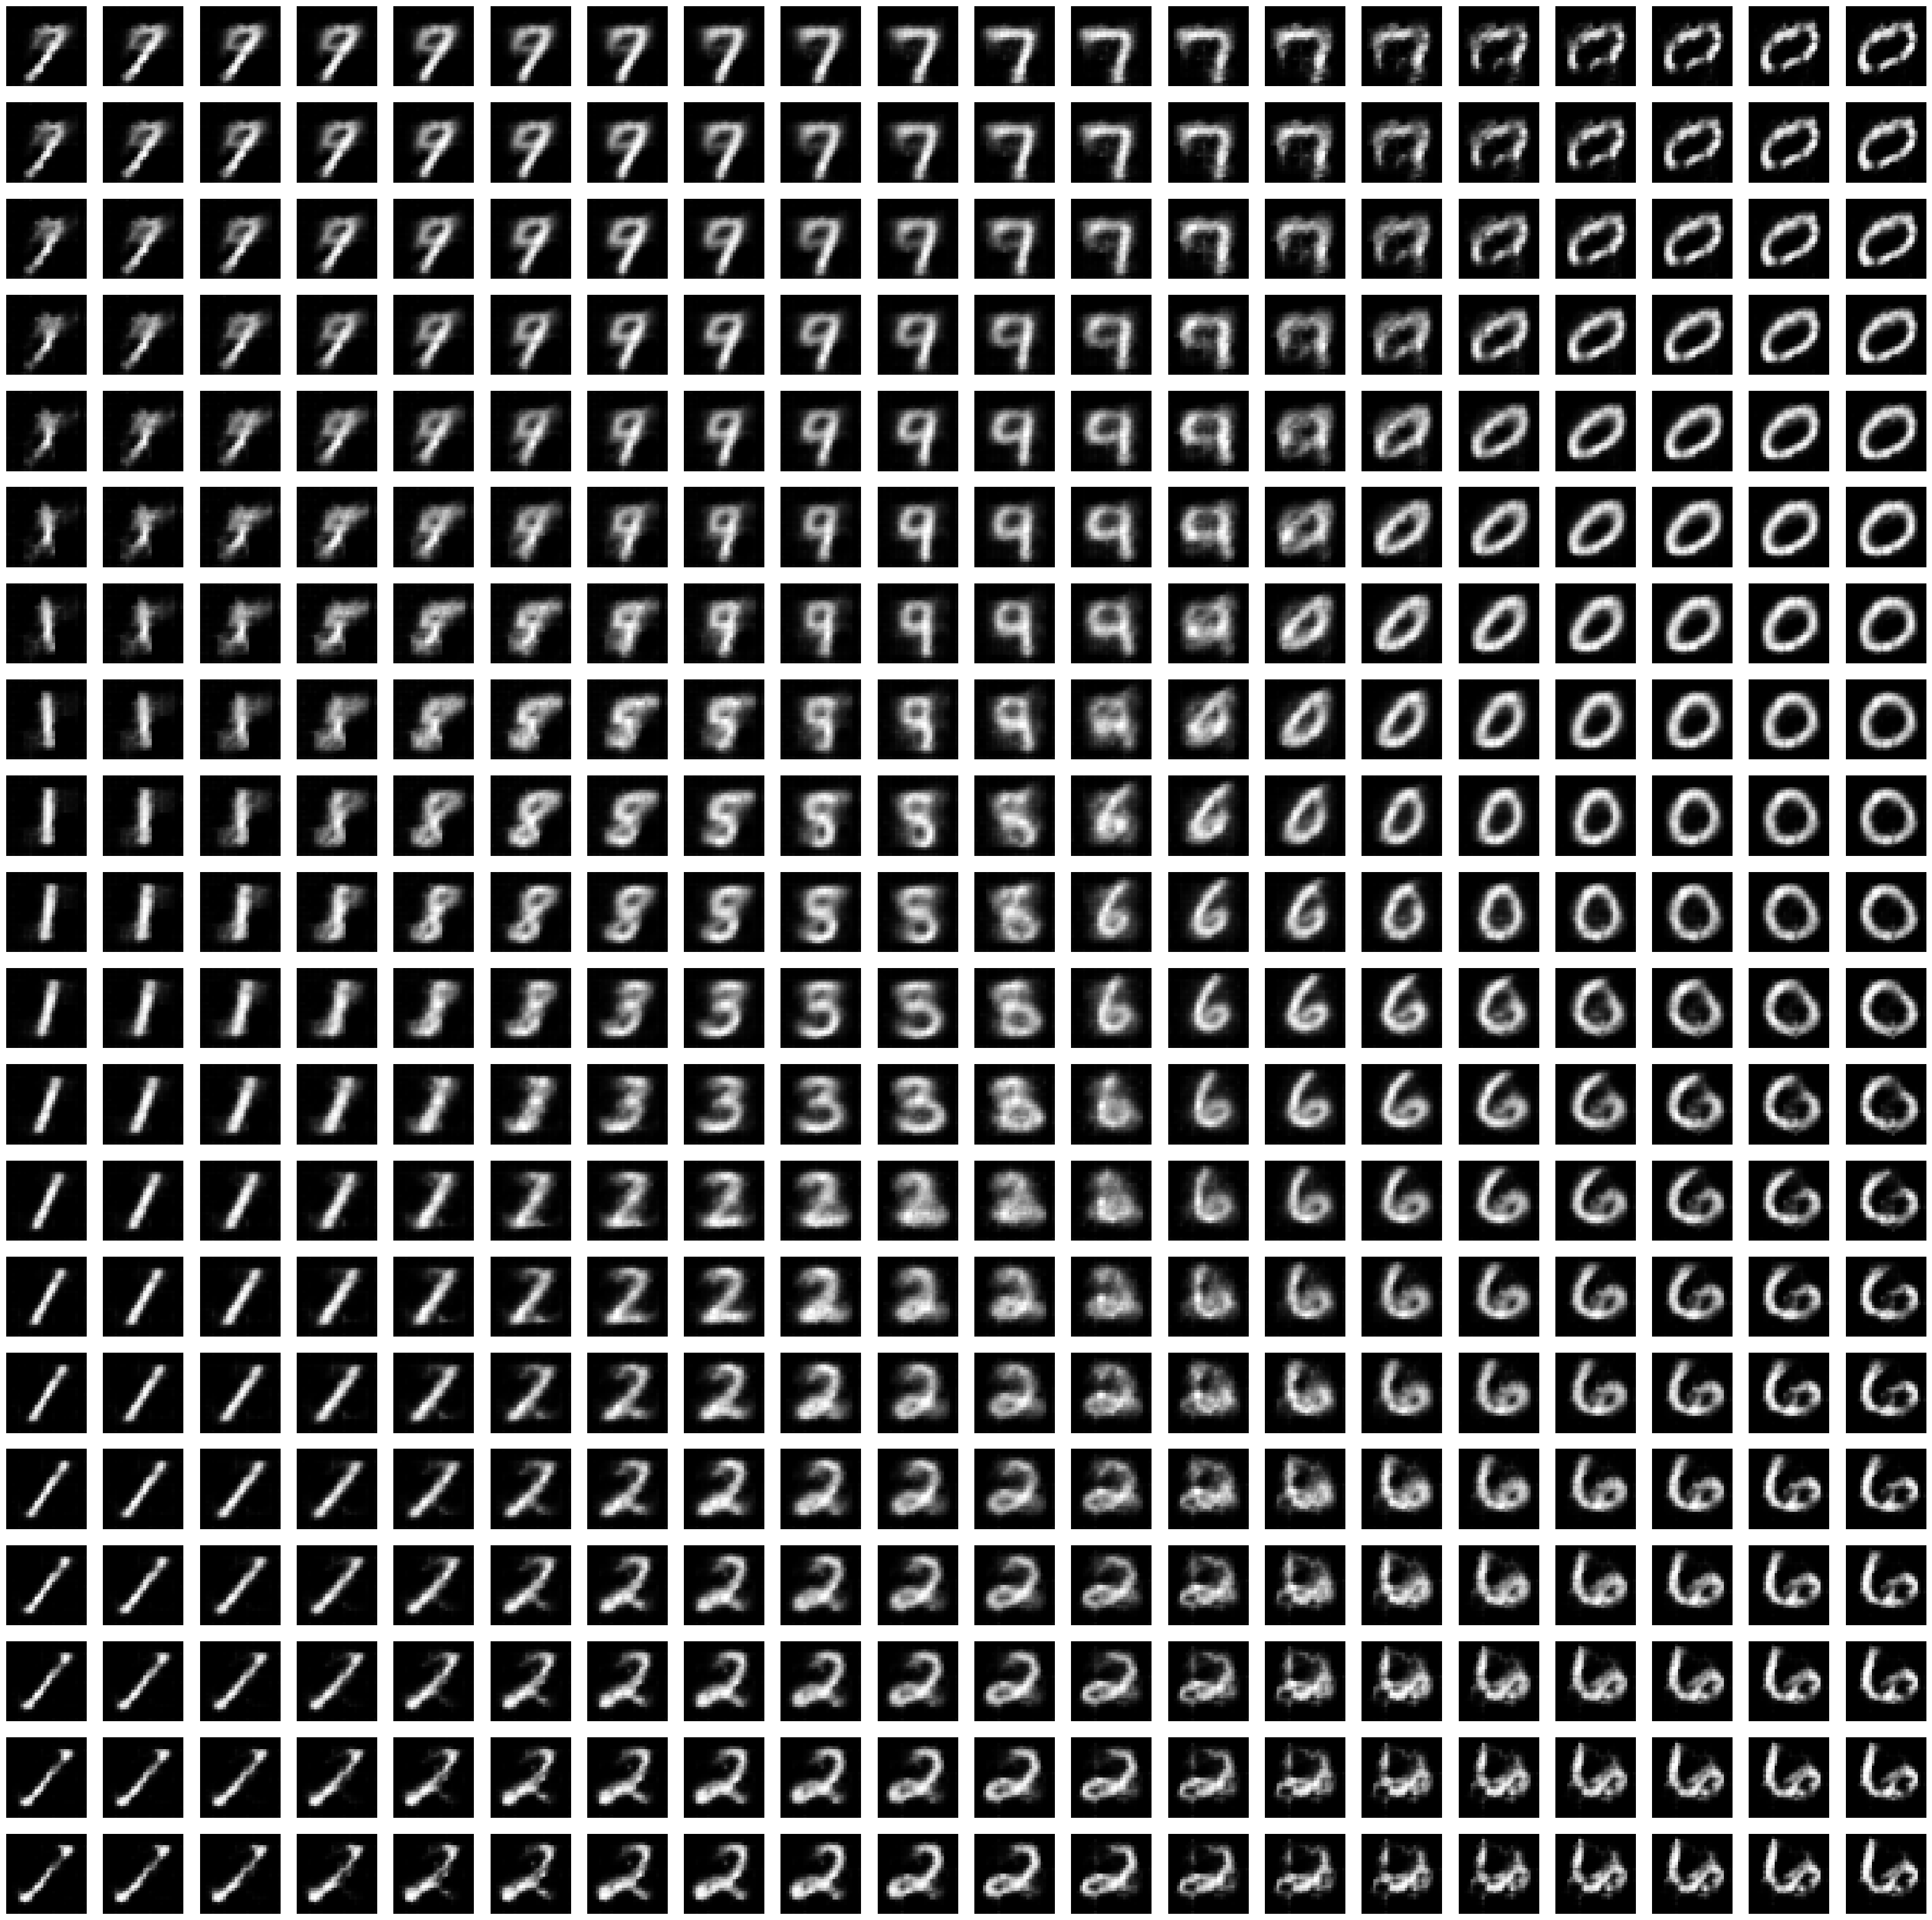

<Figure size 640x480 with 0 Axes>

In [14]:
if LATENT_SPACE_DIM == 2:
    limit = 5
    steps = 20

    step = (2.0 * limit) / steps

    vector_generation = [[-limit + j*step, limit - i*step] 
                                for i in range(steps) for j in range(steps)]

    predictions = AE.decoder(torch.Tensor(vector_generation).to(device))

    vcpi_util.show_predicted_images(steps, steps, 
                                    predictions.cpu().detach(), 10)


### Results with different latent space dimensions

![varying latent space dimension](notebook_images/varying_latent_space.png)

As can be seen with larger latent spaces we are starting to get very decent results.

# Anomaly Detection

Check if an image is consistent with the training set

![anomaly detection test](notebook_images/anomaly_detection.jpg)

Image is fed in the autoencoder, and the reconstruction is retrieved. It is expected that for images not consistent with the training set that a larger reconstruction error will be obtained

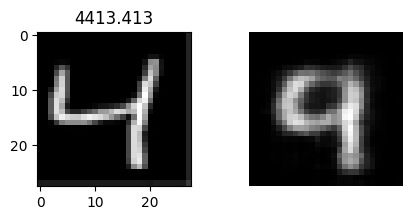

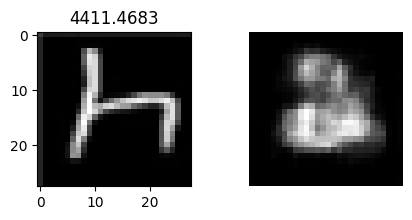

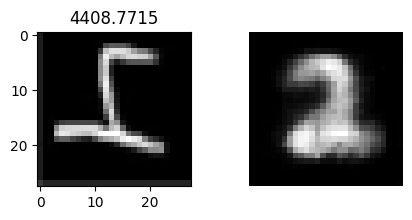

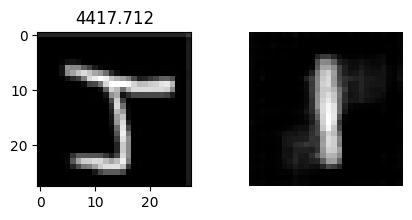

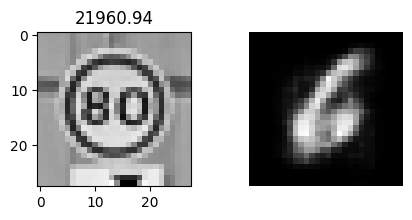

In [15]:
def anomalyDetection(image_path):

    files = glob.glob(f'{image_path}/*.jpg')
    for f in files:
        
        img = Image.open(f).convert('L').resize((28,28))
        data = transform(img).to(device).view(1,1,28,28)
        testing = AE(data)
        err = np.mean((img - testing.cpu().detach().numpy()) ** 2)

        show_anomaly_sample(img, 
                    np.transpose(testing[0].cpu().detach().numpy(),(1,2,0)), 
                    err)


image_path = 'anomalyDetectionImages'
anomalyDetection(image_path)

# Image Based Content Retrieval

For image base content retrieval, first we get the latent space for each of the images in the dataset.

Afterwards, when an image is fed into the model we use the distance from its latent space to all the gathered latent spaces. Ordering by distance allows to retrieve the $n$ images from the dataset that are closest to the input image in latent space.

In [16]:
# get latent space for training set
features = []

for i in range(train_set.__len__()):
    features.extend(AE.encoder(train_set[i][0].view(1,1,28,28).to(device)))

# build a dict from index to features from latent_space
indexes = list(range(0, train_set.__len__()))
data = {"indexes": indexes, "features": features}

Load an image

[ 2.244069  -0.7494329]


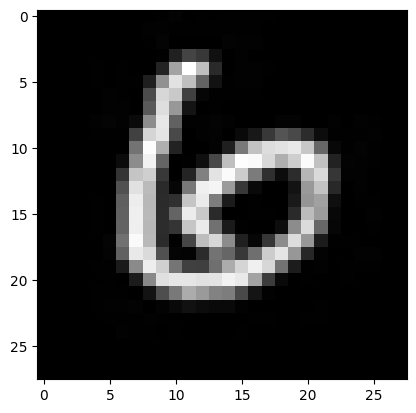

In [17]:
image_path = 'contentRetrievalImages/6.jpg'

img = Image.open(image_path).convert('L').resize((28,28))
img_tensor = transform(img).to(device).view(1,1,28,28)

#predict
dataLatent = AE.encoder(img_tensor).cpu().detach().numpy().squeeze()

print(dataLatent)
plt.imshow(img, cmap='gray')

Get 50 closest images in latent space

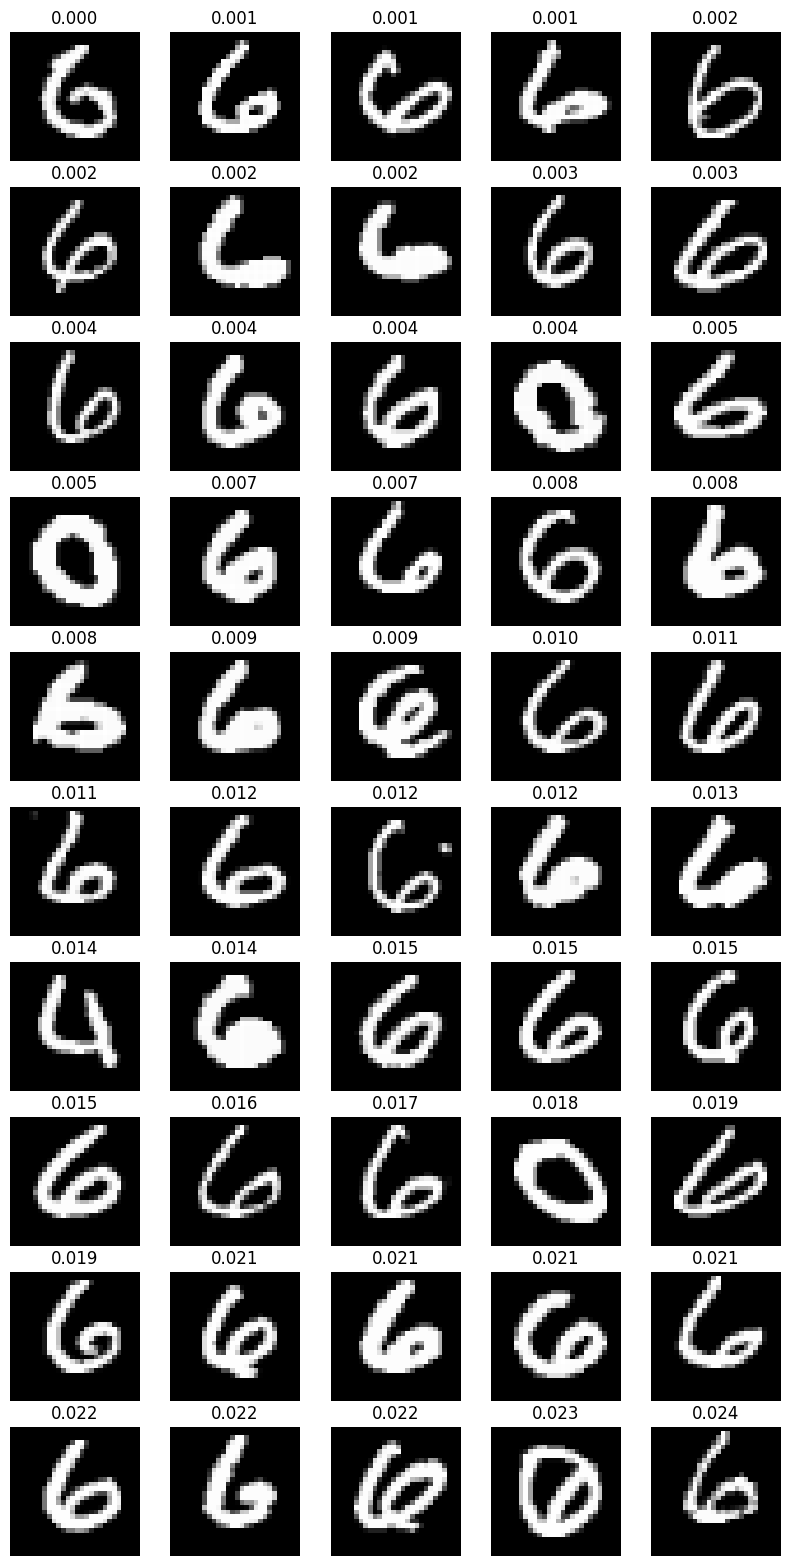

In [18]:
# compute mse error in latent space between image and elements 
# from training set
results = []
for i in range(len(data['indexes'])) :    
    err = np.sum((dataLatent - data['features'][i].cpu().detach().numpy())**2)
    err /= float(dataLatent.shape[0])
    results.append([err, i])

# sort images by error    
top50 = sorted(results)[:50]

show_content_retrieval(train_set, top50) 

# Denoiser

![denoiser](notebook_images/autoencoder_denoiser.jpg)

An autoencoder can be trained to remove noise from an image. In this simple example we will add salt noise to the MNIST set. The noisy images will be the input, and the targets will be the original images.

## Create noisy train and test data

To create the noisy dataset a custom class, derived from Dataset, is created.



In [19]:

class CustomDataLoader(torch.utils.data.Dataset):

    def __init__(self, path, transform = None):
        super().__init__()
        
        self.path = path

        self.transform = transform
        self.classes = [x.name for x in os.scandir(path) if x.is_dir()]
        self.classes_to_idx = \
            {cls_name:i for i, cls_name in enumerate(self.classes)}
        self.paths = list(pathlib.Path(path,).glob('*/*.jpg'))
        self.data = []
        self.labels = []
        for p in self.paths:
            with open(p, 'rb') as f:
            
                img = Image.open(f)
                class_name  = p.parent.name
                salt_img = skimage.util.random_noise(np.array(img), 
                                                    mode='salt', amount=0.05)
                salt_img = np.array(255*salt_img, dtype = 'uint8')
                self.data.append([salt_img, img.convert("L"), 
                                  self.classes_to_idx[class_name]])

    def __len__(self):

        return len(self.paths)    

    def __getitem__(self, idx):

        dat = self.data[idx]
        return self.transform(dat[0]), self.transform(dat[1]), dat[2] 


The MINST dataset with JPG images can be obtained in https://www.kaggle.com/datasets/scolianni/mnistasjpg?resource=download

In [20]:
dataset_set_noisy = CustomDataLoader('data/MNIST/train', transform)

train_size = int(0.8 * len(dataset_set_noisy))
val_size = len(dataset_set_noisy) - train_size

train_set_noisy, val_set_noisy = \
    torch.utils.data.random_split(dataset_set_noisy, [train_size, val_size])


In [21]:

train_loader_noisy = torch.utils.data.DataLoader(train_set_noisy, 
                                    batch_size = BATCH_SIZE, shuffle=True)
val_loader_noisy = torch.utils.data.DataLoader(val_set_noisy, 
                                    batch_size = BATCH_SIZE)

### Show images from the noisy training set



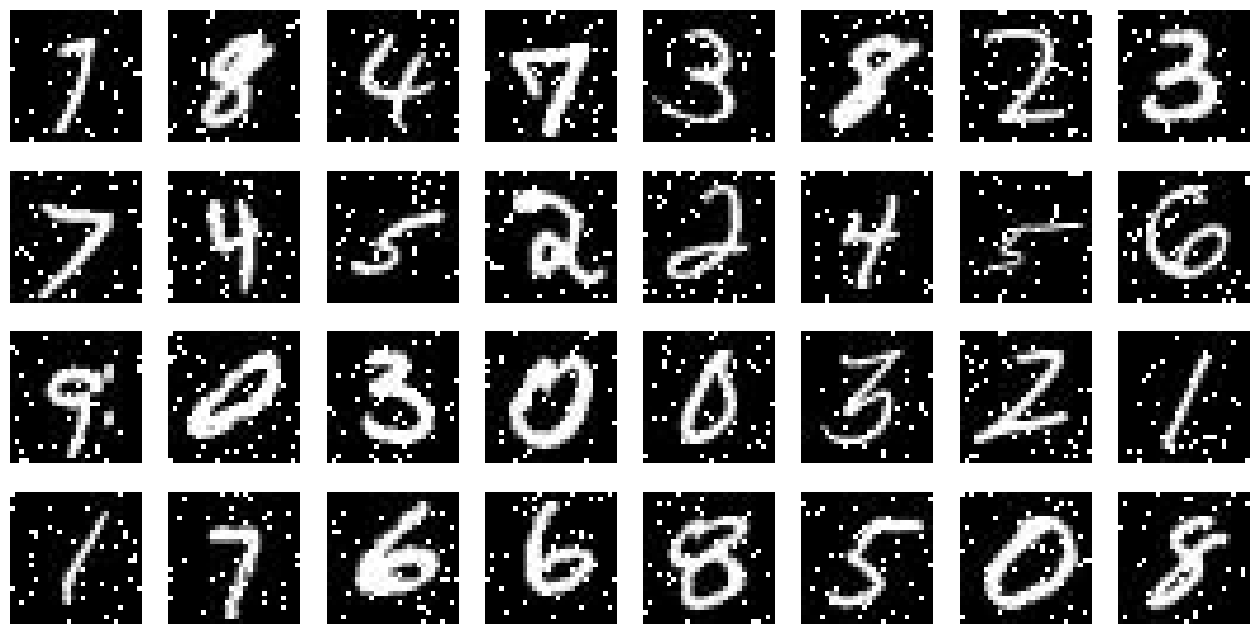

<Figure size 640x480 with 0 Axes>

In [22]:
noisy, clean, classes = next(iter(train_loader_noisy))

show_images(4,8, noisy, classes) 

### Train the autoencoder with the noisy data

In [23]:
LATENT_SPACE_DIM = 16

AE_denoise = AutoEncoder(LATENT_SPACE_DIM)
AE_denoise.to(device)  

if TRAIN:
    opt = torch.optim.Adam(AE_denoise.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', 
                                                factor = 0.1, patience=3)
    early_stop = Early_Stopping(9)
    loss_fn = torch.nn.loss_fn = torch.nn.MSELoss()

    history=train_denoiser(AE_denoise, train_loader_noisy, val_loader_noisy, 
                100, loss_fn, opt,  scheduler, early_stop, 
                f'{MODEL_PATH}/autoencoder_denoiser_{LATENT_SPACE_DIM}' )

Load the best model

In [24]:
reload =   \
    torch.load(f'{MODEL_PATH}/autoencoder_denoiser_{LATENT_SPACE_DIM}_best.pt')
print('Trained for ',reload['epoch'], ' epochs')
AE_denoise = AutoEncoder(LATENT_SPACE_DIM)
AE_denoise.to(device)
AE_denoise.load_state_dict(reload['model'])

Trained for  28  epochs


<All keys matched successfully>

### Evaluate

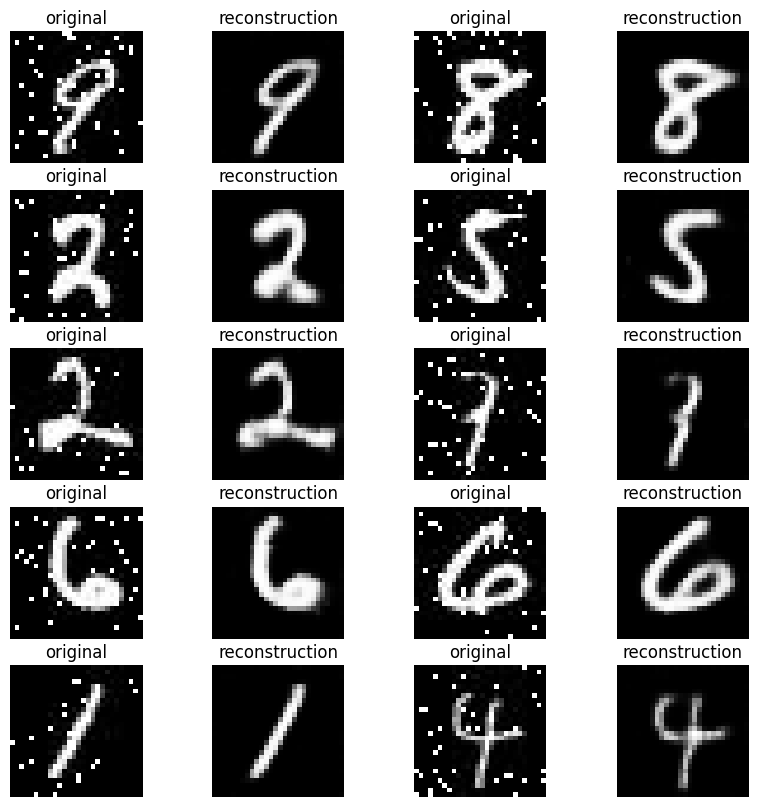

In [25]:
test_set_noisy = CustomDataLoader('data/MNIST/test', transform)
test_loader_noisy = torch.utils.data.DataLoader(test_set_noisy, 
                                        batch_size=BATCH_SIZE, shuffle=True)

noisy, _, _ = next(iter(test_loader_noisy))
recon = AE_denoise(noisy.to(device))
    
show_preds(noisy, recon, 10)